In [9]:
from EventDriven.riskmanager.utils import new_generate_spot_greeks, old_generate_spot_greeks, load_position_data_new, load_position_data
from trade.datamanager import BaseDataManager
from trade.datamanager._enums import OptionPricingModel, DivType
import pandas as pd
pd.options.plotting.backend = "plotly"

In [2]:
BaseDataManager.clear_all_caches()
BaseDataManager.CONFIG.option_model = OptionPricingModel.BINOMIAL
BaseDataManager.CONFIG.dividend_type = DivType.CONTINUOUS

2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for DividendDataManager (CACHE_NAME='dividend_data_manager')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for RatesDataManager (CACHE_NAME='rates_data_manager')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for ForwardDataManager (CACHE_NAME='forward_data_manager')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for OptionSpotDataManager (CACHE_NAME='option_spot_manager')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for SpotDataManager (CACHE_NAME='spot_data_manager')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for VolDataManager (CACHE_NAME='vol_data_manager_cache')
2026-02-08 22:46:26 [test] trade.datamanager.base INFO: Clearing cache for GreekDataManager (CACHE_NAME='greek_datamanager_cache')


In [3]:
old_data = old_generate_spot_greeks(
    opttick="AAPL20260918C260",
    start_date="2024-01-01",
    end_date="2026-02-07"
)

Fetching rates data from yfinance directly during market hours
2026-02-08 22:46:27 [test] DataManager.py CRITICAL: Extra Cols not implemented for BS Greeks
Fetching rates data from yfinance directly during market hours


In [8]:
old_data


,Vega,Vanna,Volga,Delta,Gamma,Theta,Rho,Midpoint,Closeask,Closebid
Datetime,,,,,,,,,,
2025-05-06,0.779517,0.011247,1.484691,0.282345,0.005537,-0.025090,0.639240,9.200,10.90,7.50
2025-05-07,0.763661,0.011131,1.486647,0.277654,0.005413,-0.025117,0.618088,9.100,10.25,7.95
2025-05-08,0.786337,0.010677,1.329489,0.292010,0.005368,-0.026578,0.647788,10.000,10.15,9.85
2025-05-09,0.788531,0.010834,1.361628,0.291080,0.005450,-0.026264,0.650489,9.825,9.95,9.70
2025-05-12,0.902300,0.009677,0.899101,0.349808,0.005799,-0.029900,0.822339,12.825,12.95,12.70
...,...,...,...,...,...,...,...,...,...,...
2026-02-02,0.791312,-0.002194,0.176070,0.645019,0.006386,-0.059510,0.895629,30.775,30.90,30.65
2026-02-03,0.791608,-0.001932,0.149382,0.640477,0.006299,-0.060715,0.881344,30.875,31.15,30.60
2026-02-04,0.772046,-0.003258,0.339473,0.682442,0.005806,-0.061189,0.947376,35.675,36.15,35.20


In [5]:
new_data = new_generate_spot_greeks(
    opttick="AAPL20260918C260",
    start_date="2024-01-01",
    end_date="2026-02-07"
)
new_data

2026-02-08 22:46:37 [test] trade.datamanager.vars INFO: Loading timeseries for AAPL...
2026-02-08 22:46:37 [test] trade.datamanager.utils INFO: Cutting off today's data for key: AAPL to avoid saving partial day data.
2026-02-08 22:46:37 [test] trade.datamanager.market_data INFO: Loaded spot data for symbol AAPL into cache.
2026-02-08 22:46:38 [test] trade.datamanager.utils INFO: Cutting off today's data for key: AAPL to avoid saving partial day data.
2026-02-08 22:46:38 [test] trade.datamanager.market_data INFO: Loaded chain spot data for symbol AAPL into cache.
2026-02-08 22:46:38 [test] trade.datamanager.market_data_helpers.dividends INFO: Ticker AAPL found in dividend cache.
2026-02-08 22:46:39 [test] trade.datamanager.market_data INFO: Loaded dividend data for symbol AAPL into cache.
2026-02-08 22:46:39 [test] trade.datamanager.utils INFO: Cutting off today's data for key: AAPL to avoid saving partial day data.
2026-02-08 22:46:39 [test] trade.datamanager.market_data INFO: Loaded c

,Gamma,Delta,Theta,Rho,Volga,Vega,Midpoint,Closeask,Closebid
datetime,,,,,,,,,
2025-05-06,0.005670,0.284534,-0.026680,0.645060,-0.009861,0.789020,9.200,10.90,7.50
2025-05-07,0.005539,0.279719,-0.026940,0.623503,-0.009469,0.782244,9.100,10.25,7.95
2025-05-08,0.005494,0.294235,-0.027711,0.653668,-0.008528,0.774655,10.000,10.15,9.85
2025-05-09,0.005580,0.293327,-0.027432,0.656446,-0.008900,0.778728,9.825,9.95,9.70
2025-05-12,0.005947,0.352829,-0.032195,0.830869,-0.009229,0.918975,12.825,12.95,12.70
...,...,...,...,...,...,...,...,...,...
2026-02-02,0.006498,0.650133,-0.063781,0.904295,0.001066,0.800159,30.775,30.90,30.65
2026-02-03,0.006408,0.645413,-0.064873,0.889652,0.000918,0.798928,30.875,31.15,30.60
2026-02-04,0.005901,0.687810,-0.065034,0.956609,0.001513,0.766880,35.675,36.15,35.20


In [1]:
BaseDataManager.clear_all_caches()
load_position_data_new(
    opttick="AAPL20260918C260",
    processed_option_data={},
    start="2024-01-01",
    end="2026-02-07"
)

NameError: name 'BaseDataManager' is not defined

In [13]:
BaseDataManager.CONFIG.option_model = OptionPricingModel.BINOMIAL
binom_data = new_generate_spot_greeks(
    opttick="AAPL20260918C260",
    start_date="2024-01-01",
    end_date="2026-02-07"
)
binom_data

2026-02-07 14:39:58 [test] trade.datamanager.vars INFO: Timeseries for AAPL already loaded.
2026-02-07 14:39:58 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.CONTINUOUS
2026-02-07 14:39:58 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: AAPL
2026-02-07 14:39:58 [test] trade.datamanager.utils INFO: Sanitizing data from 2017-01-01 to 2026-02-07 14:38:22.049737...
2026-02-07 14:39:58 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: AAPL
2026-02-07 14:39:58 [test] trade.datamanager.utils INFO: Sanitizing data from 2017-01-01 to 2026-02-07 14:38:22.049737...
2026-02-07 14:39:58 [test] trade.datamanager.rates INFO: Cache hit for risk-free rate timeseries key: symbol:^IRX|interval:eod|artifact_type:rates|series_id:hist|fn_interval:1D
2026-02-07 14:39:58 [test] trade.datamanager.rates INFO: Cache fully covers requested date range for risk-free rate timeseries. Key: symbol:^IRX|interval:eod|artifa

,Rho,Vega,Delta,Theta,Volga,Gamma,Midpoint,Closeask,Closebid
datetime,,,,,,,,,
2025-05-06,0.645060,0.789020,0.284534,-0.026680,-0.009861,0.005670,9.200,10.90,7.50
2025-05-07,0.623503,0.782244,0.279719,-0.026940,-0.009469,0.005539,9.100,10.25,7.95
2025-05-08,0.653668,0.774655,0.294235,-0.027711,-0.008528,0.005494,10.000,10.15,9.85
2025-05-09,0.656446,0.778728,0.293327,-0.027432,-0.008900,0.005580,9.825,9.95,9.70
2025-05-12,0.830870,0.918975,0.352829,-0.032195,-0.009229,0.005947,12.825,12.95,12.70
...,...,...,...,...,...,...,...,...,...
2026-02-02,0.904295,0.800159,0.650133,-0.063781,0.001066,0.006498,30.775,30.90,30.65
2026-02-03,0.889652,0.798928,0.645413,-0.064873,0.000918,0.006408,30.875,31.15,30.60
2026-02-04,0.956609,0.766880,0.687810,-0.065034,0.001513,0.005901,35.675,36.15,35.20


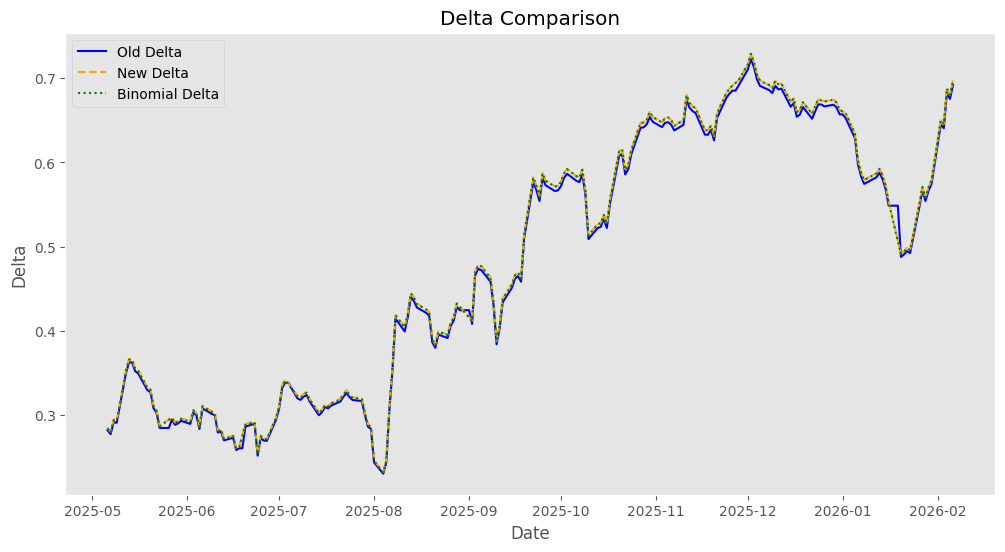

In [52]:
## Plots
import matplotlib.pyplot as plt

## Delta Comparison
plt.figure(figsize=(12, 6))
plt.plot(old_data.index, old_data["Delta"], label="Old Delta", color="blue", )
plt.plot(new_data.index, new_data["Delta"], label="New Delta", color="orange", linestyle="--")
plt.plot(binom_data.index, binom_data["Delta"], label="Binomial Delta", color="green", linestyle=":")
plt.title("Delta Comparison")
plt.xlabel("Date")
plt.ylabel("Delta")
plt.legend()
plt.grid()
plt.show()

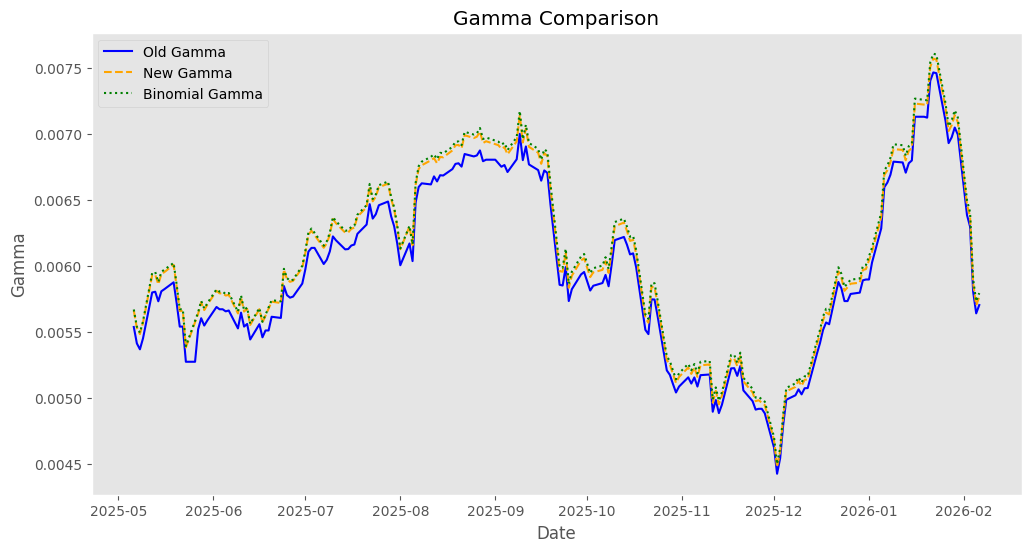

In [62]:
## Plots
import matplotlib.pyplot as plt

## Delta Comparison
plt.figure(figsize=(12, 6))
plt.plot(old_data.index, old_data["Gamma"], label="Old Gamma", color="blue", )
plt.plot(new_data.index, new_data["Gamma"], label="New Gamma", color="orange", linestyle="--")
plt.plot(binom_data.index, binom_data["Gamma"], label="Binomial Gamma", color="green", linestyle=":")
plt.title("Gamma Comparison")
plt.xlabel("Date")
plt.ylabel("Gamma")
plt.legend()
plt.grid()
plt.show()

In [39]:
new_data

## Convert to DataFrame for easier comparison
greeks = new_data.greek.timeseries
option_spot = new_data.option_spot.timeseries
data = greeks.join(option_spot[["midpoint", "closeask", "closebid"]])
data.columns = data.columns.str.capitalize()
data

,Delta,Volga,Rho,Vega,Theta,Gamma,Midpoint,Closeask,Closebid
datetime,,,,,,,,,
2025-05-06,0.285381,0.014906,0.647345,0.785890,-0.025784,0.005661,9.200,10.90,7.50
2025-05-07,0.280618,0.014932,0.625852,0.769922,-0.025805,0.005531,9.100,10.25,7.95
2025-05-08,0.295018,0.013340,0.655769,0.792500,-0.027290,0.005483,10.000,10.15,9.85
2025-05-09,0.294087,0.013665,0.658522,0.794720,-0.026970,0.005569,9.825,9.95,9.70
2025-05-12,0.353649,0.008917,0.833196,0.908825,-0.030742,0.005929,12.825,12.95,12.70
...,...,...,...,...,...,...,...,...,...
2026-02-02,0.650158,0.001991,0.904317,0.789516,-0.060587,0.006464,30.775,30.90,30.65
2026-02-03,0.645435,0.001698,0.889670,0.790056,-0.061788,0.006374,30.875,31.15,30.60
2026-02-04,0.687834,0.003726,0.956652,0.768999,-0.062251,0.005871,35.675,36.15,35.20
